# Backend experiment: open-langgraph-platform

[`open-langgraph-platform`](https://github.com/HyunjunJeon/open-langgraph-platform) is another open-source self-hosted LangGraph Platform reimplementation (FastAPI + Postgres + Redis). It has no PyPI package, so it's vendored as a git submodule (a fork with local fixes for upstream migration/auth/dependency bugs -- see README.md's \"Known upstream issues\"), run here via Docker.

This notebook is a self-contained, reproducible experiment: it starts the `open-langgraph` backend, deploys the three example agents (`researcher`, `coder`, `reviewer`), calls each one directly through `langgraph_sdk`, then runs the `supervisor` agent locally and has it orchestrate all three **via `RemoteGraph`**.


In [1]:
import sys

sys.path.insert(0, "/Users/jyje/repo/jyje/pilot-langchain-remotegraph")

from langgraph_sdk import get_sync_client

from remotegraph.backends.open_langgraph import OpenLangGraphBackend as Backend

backend = Backend()
print(backend.name, "->", backend.base_url)


open-langgraph -> http://127.0.0.1:8001


### Graph shape

`researcher`/`coder`/`reviewer` are all the same shape -- a standard `create_agent` ReAct loop (model &#8644; tools) with a different single tool each. Rendered directly from the compiled graph object, not hand-drawn.

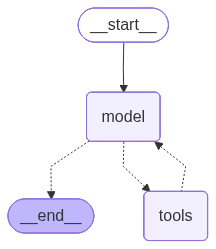

In [2]:
from IPython.display import Image

from agents.researcher.graph import graph as researcher_graph

Image(researcher_graph.get_graph(xray=True).draw_mermaid_png())


## 1. Start the backend

`backend.up()` runs `docker compose up -d --build` (postgres + redis + the app, built from `vendor/open-langgraph-platform`). First run builds the image, so this can take a minute or two.

In [3]:
SERVED_AGENTS = {
    "researcher": "agents/researcher/graph.py:graph",
    "coder": "agents/coder/graph.py:graph",
    "reviewer": "agents/reviewer/graph.py:graph",
}
backend.deploy(SERVED_AGENTS)
backend.up()
print(backend.status())


 Image open-langgraph-open-langgraph Building 


#1 [internal] load local bake definitions
#1 reading from stdin 618B done
#1 DONE 0.0s



#2 [internal] load build definition from Dockerfile
#2 transferring dockerfile: 1.76kB done
#2 DONE 0.0s

#3 [internal] load metadata for docker.io/library/python:3.13-slim-bookworm


#3 DONE 0.9s

#4 [internal] load .dockerignore
#4 transferring context:


#4 transferring context: 2B done
#4 DONE 0.1s

#5 [base 1/3] FROM docker.io/library/python:3.13-slim-bookworm@sha256:05b95397cac02b060ff1251afaa78087d92d7034369afbc8eb765631cada8257
#5 DONE 0.0s

#6 [internal] load build context


...

 Container open-langgraph-open-langgraph-1 Created 
 Container open-langgraph-postgres-1 Starting 
 Container open-langgraph-redis-1 Starting 


 Container open-langgraph-postgres-1 Started 
 Container open-langgraph-redis-1 Started 
 Container open-langgraph-postgres-1 Waiting 
 Container open-langgraph-redis-1 Waiting 


 Container open-langgraph-postgres-1 Healthy 


 Container open-langgraph-redis-1 Healthy 
 Container open-langgraph-open-langgraph-1 Starting 
 Container open-langgraph-open-langgraph-1 Started 


NAME                              IMAGE                           COMMAND                  SERVICE          CREATED         STATUS                                     PORTS
open-langgraph-open-langgraph-1   open-langgraph-open-langgraph   "sh -c 'alembic upgr…"   open-langgraph   6 seconds ago   Up Less than a second (health: starting)   0.0.0.0:8001->8000/tcp, [::]:8001->8000/tcp
open-langgraph-postgres-1         postgres:17-alpine              "docker-entrypoint.s…"   postgres         7 seconds ago   Up 6 seconds (healthy)                     0.0.0.0:6000->5432/tcp, [::]:6000->5432/tcp
open-langgraph-redis-1            redis:7-alpine                  "docker-entrypoint.s…"   redis            7 seconds ago   Up 6 seconds (healthy)                     0.0.0.0:6380->6379/tcp, [::]:6380->6379/tcp


## 2. List registered assistants

In [4]:
import time

client = get_sync_client(url=backend.base_url)

for _attempt in range(10):
    try:
        assistants = list(client.assistants.search())
        if assistants:
            break
    except Exception as exc:
        print("waiting for backend...", exc)
    time.sleep(3)

for a in assistants:
    print(a["assistant_id"], "graph_id=" + str(a.get("graph_id")))


waiting for backend... [Errno 54] Connection reset by peer


waiting for backend... [Errno 54] Connection reset by peer


## 3. Call each agent directly

In [5]:
def call(name: str, message: str) -> str:
    last = None
    stream = client.runs.stream(
        None, name, input={"messages": [{"role": "user", "content": message}]}, stream_mode="values"
    )
    for chunk in stream:
        if chunk.event == "values" and chunk.data.get("messages"):
            last = chunk.data["messages"][-1]["content"]
    return last


print(call("coder", "What is 13 * 7? Just the number."))


91


In [6]:
print(call("researcher", "What is LangGraph in one sentence?"))


LangGraph is a library built by the LangChain team that enables developers to create sophisticated, graph-based AI applications and workflows by allowing fine-grained control over how agents interact with each other and how information flows through the application.


In [7]:
print(call("reviewer", "Review this code: def add(a, b): return a + b"))


The code is correct and follows standard Python practices.

**Verdict:** ✅ No issues found.


## 4. Run the supervisor pipeline via RemoteGraph

The supervisor never imports `researcher`/`coder`/`reviewer` directly -- it only knows the backend's base URL and calls them through `langgraph.pregel.remote.RemoteGraph`, exactly as it would for a real LangGraph Platform deployment.

In [8]:
import os

os.environ["REMOTEGRAPH_BASE_URL"] = backend.base_url

sys.path.insert(0, "/Users/jyje/repo/jyje/pilot-langchain-remotegraph")
from agents.supervisor.graph import graph as supervisor_graph

task = "Write a one-line python function that returns the square of a number."
result = supervisor_graph.invoke({"task": task})
print("--- research ---")
print(result["research"])
print()
print("--- code ---")
print(result["code"])
print()
print("--- review ---")
print(result["review"])


--- research ---
```python
square = lambda x: x**2
```

Or, if you prefer a standard function definition (which is also on one line):

```python
def square(x): return x**2
```

--- code ---
```python
square = lambda x: x**2
```

--- review ---
The code is correct and adheres to good Python style for this simple use case.

**Verdict:** Correct and stylistically sound.


## 5. Tear down

In [9]:
backend.down()
print(backend.status())


 Container open-langgraph-open-langgraph-1 Stopping 


 Container open-langgraph-open-langgraph-1 Stopped 
 Container open-langgraph-open-langgraph-1 Removing 
 Container open-langgraph-open-langgraph-1 Removed 
 Container open-langgraph-redis-1 Stopping 
 Container open-langgraph-postgres-1 Stopping 


 Container open-langgraph-redis-1 Stopped 
 Container open-langgraph-redis-1 Removing 
 Container open-langgraph-redis-1 Removed 
 Container open-langgraph-postgres-1 Stopped 
 Container open-langgraph-postgres-1 Removing 


 Container open-langgraph-postgres-1 Removed 
 Network open-langgraph_default Removing 
 Network open-langgraph_default Removed 


NAME      IMAGE     COMMAND   SERVICE   CREATED   STATUS    PORTS
